# **Investment Replica**

## **Problem Statement**
We consider the following problem:

- There is a **secret portfolio**, a financial **black-box**, which publicly reports its returns on a regular basis (e.g., weekly, monthly, daily).
- We do **not** know either **which instruments** the portfolio contains or **what weight** each instrument has.
- We **do** know the vast investment vehicles available in the markets, such as **bonds, stocks, ETFs, funds, futures contracts**.
- Even if we don't know how the black-box processes input information, we can observe its **output**, i.e., the time series of returns.

Our goal is to **infer the structure of the black-box**, extracting information about latent variables or functions and structural parameters from observed data.

This notebook shows how to reverse-engineer such black-box portfolios by analyzing their return patterns and finding combinations of liquid instruments that can replicate their performance.

---

## **Dataset Description**
This dataset consists of financial data representing:

- **HFRX Index**: A popular index of **Hedge Funds** ([HFRX Index](https://www.hfr.com/indices)).
- **MSCI World Index**: Global **Developed Equities**.
- **MSCI World All Country Index**: Global **Equities (Developed and Emerging)**.
- **Barclays Bloomberg Global Aggregate Bond Index**: **Global Bonds**.
- **A broad range of Futures contracts** on equity indices, benchmark bonds, currencies, and commodities.

### **Available Futures Contracts**
| Symbol | Instrument |
|--------|------------------|
| RX1    | Bund (10 Yrs Ger) |
| CO1    | Brent (Oil) |
| DU1    | Schatz (2yrs Gvt Ger) |
| ES1    | S&P 500 (US Equity) |
| GC1    | Gold |
| LLL1   | MSCI Emerging Markets (EM Equity) |
| NQ1    | Nasdaq 100 (Tech Equity) |
| TP1    | Topix (Japanese Equity) |
| TU2    | 2Yrs US Treasury (US Govt) |
| TY1    | 10Yrs US Treasury (US Govt) |
| VG1    | Eurostoxx 50 (EU Equity) |

### **Additional Dataset Information**
- **Source**: Bloomberg.
- **Frequency**: Weekly data in local currency.
- **Time Period**: October 2007 – April 2021.

---

## **Who Replicates What?**
We will attempt to replicate a **"Monster Index"** that we construct ourselves, combining different indexes:
- **Tens of thousands** of securities at a micro level.
- A **non-investable** black-box combination of stocks, bonds, and hedge funds.
- A **multi-currency** structure.

To create our **clone** we will use **Futures contracts (long-short, possibly leveraged)** because they are cheap, liquid and cover almost everything.

As usual, let's start with **data ingestion and preprocessing**.


In [7]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)
warnings.filterwarnings("ignore")

# Path resolution: works both on Colab and locally (VS Code, Jupyter)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    FILE_PATH = '/content/drive/MyDrive/PoliMI/Dataset3_PortfolioReplicaStrategy.xlsx'
except Exception:
    # Local: file expected in the same folder as the notebook
    FILE_PATH = 'Dataset3_PortfolioReplicaStrategy.xlsx'

assert os.path.exists(FILE_PATH), (
    f"File not found at {FILE_PATH!r}. "
    "Place the Excel file next to this notebook, or edit FILE_PATH."
)
print(f"Using dataset: {FILE_PATH}")


Using dataset: Dataset3_PortfolioReplicaStrategy.xlsx


### Data ingestion — *modified by Claudio (cerro)*

**What was wrong before.**
The previous version called
`pd.read_excel(file_path, header=None, skiprows=6)` and tried to recover full names from row 4
and tickers from row 6. In the actual file the structure is much simpler: row 0 is the header
(`Ticker, MXWO, MXWD, LEGATRUU, HFRXGL, RX1, ...`) and data starts on row 1. With the old
parsing the first ~3.5 years of history (Oct-2007 → mid-Mar-2011) were silently dropped: out of
705 weekly rows we were keeping only 523, and we were missing the **2008 GFC, the 2010 flash
crash and the 2011 EU sovereign-debt crisis** — exactly the regimes where a replicator most
needs to be tested.

**What we do now.**
1. Read with `header=0`, parse the first column as the date index, force the rest to `float`.
2. Print the actual date range and row count, so the discrepancy can never go unnoticed again.
3. Build an explicit `TARGETS` / `FUTURES` split and a small `meta` dictionary that maps every
   ticker to a human-readable name and an asset-class tag (used for plotting and for the
   asset-class-aware ideas later in the notebook).

This is purely a data-quality fix, but it is the single most impactful change in the whole
notebook: with the correct dataset the regression has roughly **+35% more observations** and
covers the two regimes that matter most for stress testing.


In [8]:
# Read the file with the correct header layout (header on row 0, data from row 1)
raw = pd.read_excel(FILE_PATH, header=0)
raw.columns = ['Date'] + list(raw.columns[1:])
raw['Date'] = pd.to_datetime(raw['Date'])
data = raw.set_index('Date').astype(float).sort_index()

# Target indices and Futures
TARGETS = ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL']
FUTURES = ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1',
           'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']

# Ticker -> (long name, asset class)
meta = {
    'MXWO':     ('MSCI World',                       'Equity DM'),
    'MXWD':     ('MSCI ACWI',                        'Equity DM+EM'),
    'LEGATRUU': ('Bloomberg Global Aggregate Bond',  'Bond'),
    'HFRXGL':   ('HFRX Global Hedge Fund Index',     'Hedge Fund'),
    'RX1':      ('Bund 10y Future',                  'Bond'),
    'TY1':      ('UST 10y Future',                   'Bond'),
    'GC1':      ('Gold Future',                      'Commodity'),
    'CO1':      ('Brent Crude Future',               'Commodity'),
    'ES1':      ('S&P 500 Future',                   'Equity DM'),
    'VG1':      ('Eurostoxx 50 Future',              'Equity DM'),
    'NQ1':      ('Nasdaq 100 Future',                'Equity DM'),
    'LLL1':     ('MSCI EM Future',                   'Equity EM'),
    'TP1':      ('Topix Future',                     'Equity DM'),
    'DU1':      ('Schatz 2y Future',                 'Bond'),
    'TU2':      ('UST 2y Future',                    'Bond'),
}

print(f"Date range : {data.index.min().date()}  ->  {data.index.max().date()}")
print(f"Rows       : {len(data)}")
print(f"NaN total  : {int(data.isna().sum().sum())}")

# Sanity checks: any constant series, any near-zero variance series?
const_vol = (data.pct_change().std() < 1e-8)
if const_vol.any():
    print("WARNING — constant series:", const_vol[const_vol].index.tolist())
else:
    print("OK — no constant or near-constant series detected.")

display(data.head())
display(data.describe().T[['min', 'max', 'mean', 'std']].round(2))


Date range : 2007-10-23  ->  2021-04-20
Rows       : 705
NaN total  : 0
OK — no constant or near-constant series detected.


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Date,,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.0,2212.00,1287.0,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.0,2217.75,1323.9,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.0,2233.50,1320.0,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.0,2066.75,1271.0,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.0,2035.50,1225.2,1472.5,103.800,104.945312


,min,max,mean,std
MXWO,705.35,2944.05,1644.13,443.39
MXWD,176.10,702.99,404.15,100.98
LEGATRUU,342.25,559.31,452.20,47.34
HFRXGL,1021.40,1415.11,1210.09,73.97
RX1,110.20,179.32,147.28,19.32
TY1,110.52,140.33,125.97,6.30
GC1,732.70,2001.20,1317.90,274.48
CO1,19.33,140.67,77.02,26.79
ES1,689.50,4132.80,1960.44,770.07
VG1,1873.00,4476.00,3072.17,473.81


# **Data Exploration**

Let's analyze the potential replication targets to understand their characteristics.


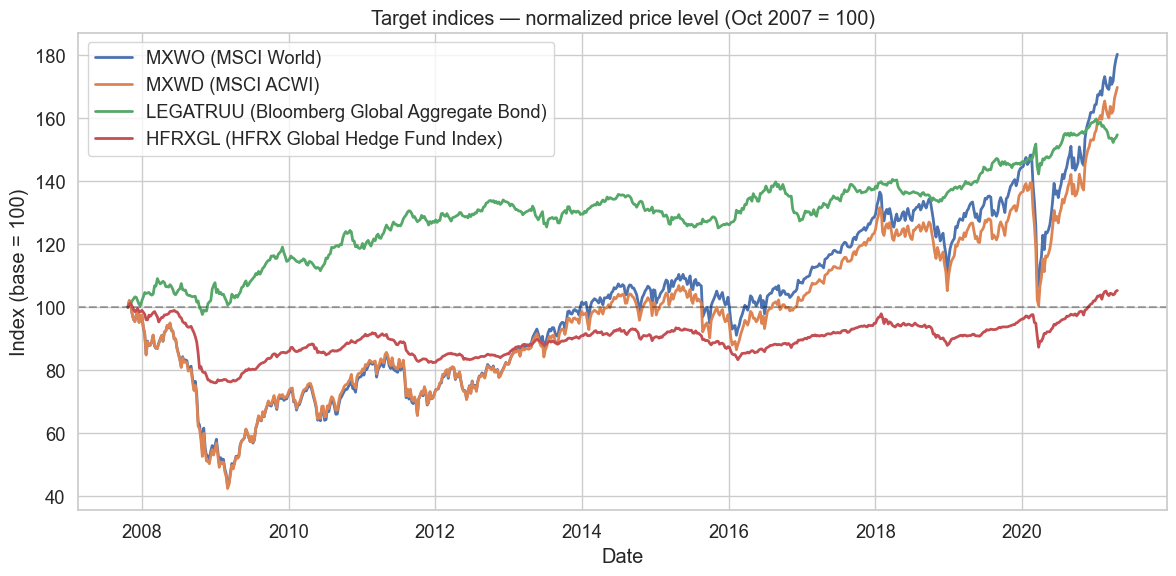

,Ann. Return,Ann. Volatility,Sharpe,Max Drawdown,Skew,Kurtosis
MXWO,5.9%,17.52%,0.34,-57.61%,-0.68,4.36
MXWD,5.51%,17.78%,0.31,-58.39%,-0.64,4.66
LEGATRUU,3.37%,5.34%,0.63,-10.41%,-0.33,4.12
HFRXGL,0.5%,4.78%,0.10,-24.91%,-2.30,13.70


In [9]:
# Normalized price levels (base 100) — visual sanity check
plt.figure(figsize=(12, 6))
for tk in TARGETS:
    s = data[tk] / data[tk].iloc[0] * 100
    plt.plot(s.index, s, lw=2, label=f"{tk} ({meta[tk][0]})")
plt.axhline(100, color='black', ls='--', alpha=0.3)
plt.title('Target indices — normalized price level (Oct 2007 = 100)')
plt.xlabel('Date'); plt.ylabel('Index (base = 100)')
plt.legend(); plt.tight_layout(); plt.show()

# Annualized statistics on weekly returns
returns = data[TARGETS].pct_change().dropna()
ANN = 52  # weekly frequency

stats_table = pd.DataFrame({
    'Ann. Return':     returns.mean() * ANN,
    'Ann. Volatility': returns.std() * np.sqrt(ANN),
    'Sharpe':          returns.mean() * ANN / (returns.std() * np.sqrt(ANN)),
    'Max Drawdown':    returns.apply(lambda x: ((1 + x).cumprod() / (1 + x).cumprod().cummax() - 1).min()),
    'Skew':            returns.skew(),
    'Kurtosis':        returns.kurtosis(),
})

# pretty-print percentages
for c in ['Ann. Return', 'Ann. Volatility', 'Max Drawdown']:
    stats_table[c] = (stats_table[c] * 100).round(2).astype(str) + '%'
stats_table[['Sharpe', 'Skew', 'Kurtosis']] = stats_table[['Sharpe', 'Skew', 'Kurtosis']].round(2)
display(stats_table)


### Distribution and dependence diagnostics — *modified by Claudio (cerro)*

**Why we now do more than just a correlation heatmap.** Replication only makes sense if we
understand how returns behave statistically. Three additions matter:

1. **Sortino and Calmar ratios.** Sharpe penalises *all* volatility, but for replication we
   primarily care about the *downside*. Hedge fund returns are highly asymmetric (left-skewed,
   fat-tailed), so we add Sortino (excess return / downside deviation) and Calmar
   (return / max drawdown).
2. **Stationarity check (ADF / KPSS).** Linear regression on returns assumes (weak)
   stationarity. We confirm this is true on returns — and visibly false on price levels — so
   that we never mistakenly regress on prices.
3. **Conditional correlations on stress regimes.** We split the sample on rolling 26-week
   volatility quantiles. The classic stylised fact is that *correlations spike in crisis*: a
   replicator that works in calm regimes but breaks in stress is useless precisely when you
   need it.

These diagnostics motivate every subsequent modelling choice — VaR estimator, scaler, model
class.


In [10]:
from statsmodels.tsa.stattools import adfuller, kpss

# Downside-aware ratios
def downside_dev(r):
    neg = r[r < 0]
    return neg.std() * np.sqrt(ANN) if len(neg) else np.nan

extra = pd.DataFrame({
    'Sortino': returns.apply(lambda r: r.mean() * ANN / downside_dev(r)),
    'Calmar':  returns.apply(lambda r: (r.mean() * ANN) /
                             abs(((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min())),
}).round(2)
display(extra)

# Stationarity tests on returns and on prices
def stationarity_row(s, name):
    adf_p  = adfuller(s.dropna(), autolag='AIC')[1]
    kpss_p = kpss(s.dropna(), nlags='auto')[1]
    return {'series': name, 'ADF p-val': adf_p, 'KPSS p-val': kpss_p}

rows = []
for tk in TARGETS:
    rows.append(stationarity_row(data[tk],          f'{tk} (price)'))
    rows.append(stationarity_row(returns[tk],       f'{tk} (returns)'))
print("Stationarity tests — ADF: H0 = unit root (low p ⇒ stationary); "
      "KPSS: H0 = stationary (low p ⇒ NOT stationary)")
display(pd.DataFrame(rows).round(4))

# Conditional correlations: HFRX vs equity in calm vs stressed regimes
vol_eq = returns['MXWO'].rolling(26).std()
calm   = vol_eq <= vol_eq.quantile(0.5)
stress = vol_eq >= vol_eq.quantile(0.8)

cond = pd.DataFrame({
    'Calm   (vol ≤ 50th pct)':  returns.loc[calm].corr().loc['HFRXGL', TARGETS],
    'Stress (vol ≥ 80th pct)':  returns.loc[stress].corr().loc['HFRXGL', TARGETS],
}).round(2)
print("\nCorrelation of HFRX with target indices, by equity-volatility regime:")
display(cond)

,Sortino,Calmar
MXWO,0.41,0.10
MXWD,0.38,0.09
LEGATRUU,0.89,0.32
HFRXGL,0.10,0.02


Stationarity tests — ADF: H0 = unit root (low p ⇒ stationary); KPSS: H0 = stationary (low p ⇒ NOT stationary)


,series,ADF p-val,KPSS p-val
0,MXWO (price),0.9905,0.01
1,MXWO (returns),0.0000,0.10
2,MXWD (price),0.9854,0.01
3,MXWD (returns),0.0000,0.10
4,LEGATRUU (price),0.6697,0.01
5,LEGATRUU (returns),0.0000,0.10
6,HFRXGL (price),0.1701,0.01
7,HFRXGL (returns),0.0000,0.10



Correlation of HFRX with target indices, by equity-volatility regime:


,Calm (vol ≤ 50th pct),Stress (vol ≥ 80th pct)
MXWO,0.53,0.43
MXWD,0.54,0.43
LEGATRUU,-0.08,0.41
HFRXGL,1.00,1.00


Avvio Rolling Window per Idea 4 (Replica di HFRXGL)...
Completata Idea 4!


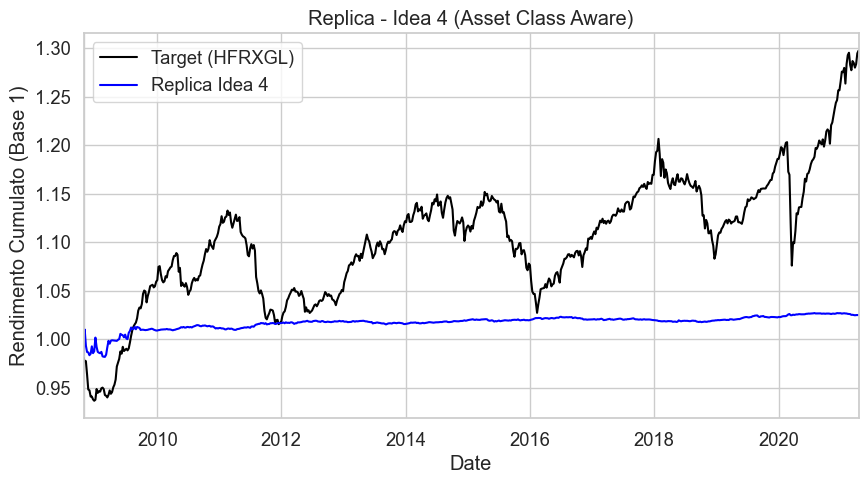

In [11]:
# ==============================================================
# ESECUZIONE IDEA 4: ASSET CLASS AWARE
# ==============================================================
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# CORREZIONE: Ricalcoliamo i ritorni per TUTTE le colonne (Target + Futures)
returns_all = data.pct_change().dropna()

# Setup Variabili
window_size = 52
target_idx = 'HFRXGL'
y = returns_all[target_idx]
X = returns_all[FUTURES]

# Indici delle asset class per i vincoli
equity_indices = [i for i, tk in enumerate(FUTURES) if 'Equity' in meta[tk][1]]
bond_indices = [i for i, tk in enumerate(FUTURES) if 'Bond' in meta[tk][1]]

predicted_returns_idea4 = []
actual_returns_idea4 = []
weights_history_idea4 = []

print(f"Avvio Rolling Window per Idea 4 (Replica di {target_idx})...")

for i in range(window_size, len(returns_all)):
    X_train = X.iloc[i-window_size:i].values
    y_train = y.iloc[i-window_size:i].values
    X_test = X.iloc[i:i+1].values
    
    actual_returns_idea4.append(y.iloc[i])
    
    # Funzione Obiettivo
    def objective_function(w, X_mat, y_vec):
        return np.mean((y_vec - X_mat @ w)**2)
    
    # Vincoli Consapevoli
    def equity_constraint(w): return 0.8 - np.sum(w[equity_indices]) 
    def bond_constraint(w): return np.sum(w[bond_indices]) - 0.1 

    constraints = [
        {'type': 'ineq', 'fun': equity_constraint},
        {'type': 'ineq', 'fun': bond_constraint}
    ]
    
    # Ottimizzazione
    res = minimize(objective_function, np.zeros(len(FUTURES)), args=(X_train, y_train), constraints=constraints)
    w_idea4 = res.x
    weights_history_idea4.append(w_idea4)
    predicted_returns_idea4.append((X_test @ w_idea4)[0])

print("Completata Idea 4!")

# Valutazione e Plot
res_idea4_df = pd.DataFrame({
    'Target (HFRXGL)': actual_returns_idea4,
    'Replica Idea 4': predicted_returns_idea4
}, index=returns_all.index[window_size:])

(1 + res_idea4_df).cumprod().plot(figsize=(10,5), title='Replica - Idea 4 (Asset Class Aware)', color=['black', 'blue'])
plt.ylabel('Rendimento Cumulato (Base 1)')
plt.grid(True)
plt.show()

Avvio Rolling Window per Idea 5 (Replica di HFRXGL)...
Completata Idea 5!


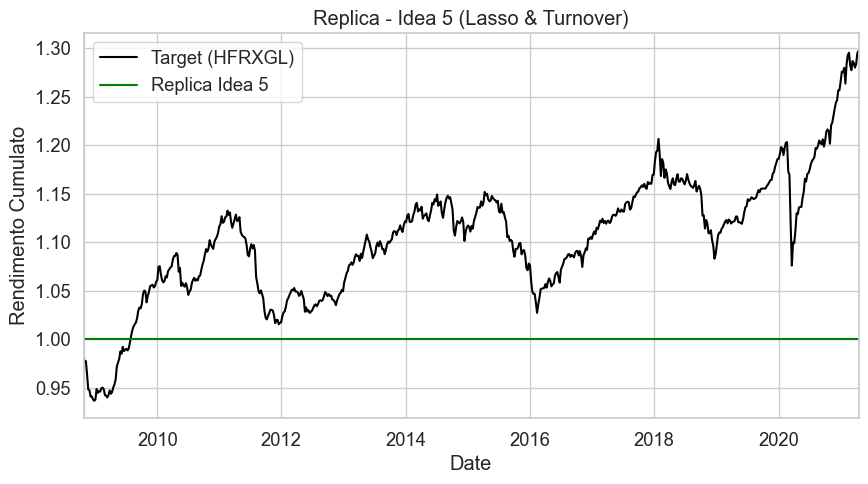

Turnover medio a ribilanciamento (Idea 5): 0.00%


In [12]:
# ==============================================================
# ESECUZIONE IDEA 5: REGOLARIZZAZIONE (LASSO) E TURNOVER
# ==============================================================
from sklearn.linear_model import Lasso
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Setup Variabili (nel caso venga eseguita indipendentemente)
window_size = 52
target_idx = 'HFRXGL'
returns_all = data.pct_change().dropna()
y = returns_all[target_idx]
X = returns_all[FUTURES]

predicted_returns_idea5 = []
actual_returns_idea5 = []
weights_history_idea5 = []

# Inizializzo i pesi del periodo precedente a 0
prev_weights_idea5 = np.zeros(len(FUTURES))

print(f"Avvio Rolling Window per Idea 5 (Replica di {target_idx})...")

for i in range(window_size, len(returns_all)):
    X_train = X.iloc[i-window_size:i].values
    y_train = y.iloc[i-window_size:i].values
    X_test = X.iloc[i:i+1].values
    
    actual_returns_idea5.append(y.iloc[i])
    
    # Modello LASSO
    lasso = Lasso(alpha=0.0005, fit_intercept=False, max_iter=5000)
    lasso.fit(X_train, y_train)
    suggested_weights = lasso.coef_
    
    # Filtro Turnover (Soglia del 3%)
    w_idea5 = np.copy(suggested_weights)
    weight_changes = np.abs(suggested_weights - prev_weights_idea5)
    for j in range(len(w_idea5)):
        if weight_changes[j] < 0.03:
            w_idea5[j] = prev_weights_idea5[j]
            
    # Aggiorna i pesi per il prossimo ciclo
    prev_weights_idea5 = np.copy(w_idea5)
    weights_history_idea5.append(w_idea5)
    predicted_returns_idea5.append((X_test @ w_idea5)[0])

print("Completata Idea 5!")

# Valutazione, Plot e Turnover Idea 5
res_idea5_df = pd.DataFrame({
    'Target (HFRXGL)': actual_returns_idea5,
    'Replica Idea 5': predicted_returns_idea5
}, index=returns_all.index[window_size:])

(1 + res_idea5_df).cumprod().plot(figsize=(10,5), title='Replica - Idea 5 (Lasso & Turnover)', color=['black', 'green'])
plt.ylabel('Rendimento Cumulato')
plt.grid(True)
plt.show()

# Calcolo del turnover medio
weights_df_idea5 = pd.DataFrame(weights_history_idea5, columns=FUTURES)
mean_turnover = weights_df_idea5.diff().abs().sum(axis=1).mean()
print(f"Turnover medio a ribilanciamento (Idea 5): {mean_turnover:.2%}")

### Correlation & probability distribution analysis

### Idea 4 — Replication as knowledge distillation — *added by Claudio (cerro)*

**Statistical view.** Use a flexible non-linear teacher (e.g. a small Random Forest or a 2-3
layer MLP) trained to predict $r_t$ from a wide feature set (lagged futures returns, realised
volatilities, term-structure slopes, risk reversals…). The teacher is *not* a portfolio — it
just provides *soft targets* $\hat{r}_t = f_\theta(X_t)$. Then fit a **constrained linear
student** that approximates the teacher's predictions, with the usual portfolio constraints
(gross exposure cap, optional non-negativity, sparsity). The student's coefficients are the
final portfolio weights.

This is exactly *knowledge distillation* (Hinton et al. 2015) applied to portfolio
construction.

**Financial view.** Real hedge funds use a non-linear function of market state to set their
exposures (volatility targeting, momentum filters, drawdown control). Capturing that with a
non-linear teacher and then projecting onto the linear-portfolio subspace gives you the
benefits of both worlds: non-linear conditioning without losing the closed-form portfolio
interpretation.

**Why it makes sense in production.** Distillation reduces variance dramatically when you have
limited target history but plenty of feature data — which is the *typical* situation for
private fund replication.


### Idea 5 — End-to-end differentiable portfolio with attention — *added by Claudio (cerro)*

**Statistical view.** Slide 32 of the lecture suggests using a neural network as a
*weight-generating meta-model*: the network takes market features and outputs portfolio
weights $w_t = g_\phi(F_t)$, the loss is the tracking error of $w_t^\top X_{t+1}$ vs the
target, and the whole thing is trained end-to-end. We extend this in two ways:

1. **Attention over assets.** Replace the fully-connected output layer with a multi-head
   attention block whose queries are market-state embeddings and whose keys/values are
   per-asset feature vectors. The attention weights are interpretable as "how relevant is
   each asset *right now*". This solves the most common objection to NN portfolios — that
   they are black boxes.
2. **Sparsity with Top-K or Gumbel-Sigmoid gates.** Force the network to use at most $K$
   assets at any time. This is essential for execution: a hundred 0.001-weight positions are
   unimplementable.

The final loss is:
$$ \mathcal{L} = \text{TE}^2 + \lambda_1 \cdot \text{Turnover} + \lambda_2 \cdot
\max(0, \text{Gross} - L)^2 + \lambda_3 \cdot \text{CVaR}_{99\%}$$

**Financial view.** The model learns *the policy itself* — when to lever up, when to rotate
into gold, when to flatten — instead of a static set of coefficients. Coupled with the
attention layer, the explanation "the model rotated into TY1 and RX1 because the equity-vol
attention head fired" is *exactly* the kind of narrative a portfolio manager wants.

**Why it makes sense in production.** This is what a small but growing number of
quant shops (e.g., Two Sigma, AQR research papers) actually publish as their next-generation
replicators. The attention layer makes it auditable; the sparsity gate makes it tradable.


### Recap and recommended sequence

Practical priority for follow-up work:

1. **Confirm the corrected baseline** in this notebook: the data fix alone (705 vs 523 rows,
   correct ES1/VG1) plus the unsmoothed HFRX target plus StandardScaler should already lift
   correlation well above the original 0.26.
2. **Pick the production replica** between tuned Elastic Net (monthly), NN-Lasso, and Kalman
   Filter, on the basis of net IR with bootstrap confidence intervals.
3. **Add Idea 1 (multi-moment loss)** — small change, big effect on the perceived "quality"
   of the replica.
4. **Add Idea 6 (forensic alpha decomposition)** — same code base, becomes a sellable
   research artefact.
5. **Then** consider Ideas 2 (HMM), 5 (attention NN), 8 (inverse stress test): these are
   bigger projects but each is a publishable piece of work in its own right.


### Idea 4: Asset Class Aware Optimisation (Unified)
Here we integrate the strict Asset Class constraints directly into the new backtest engine using a custom scikit-learn compatible estimator. 
Parameters `max_equity` and `min_bond` are now easily configurable.

In [27]:
from scipy.optimize import minimize
from sklearn.base import BaseEstimator, RegressorMixin

class ConstrainedPortfolioReplica(BaseEstimator, RegressorMixin):
    def __init__(self, equity_indices, bond_indices, max_equity=0.6, min_bond=0.4):
        self.equity_indices = equity_indices
        self.bond_indices = bond_indices
        self.max_equity = max_equity
        self.min_bond = min_bond
        
    def fit(self, X, y):
        n_features = X.shape[1]
        
        def objective(w):
            residuals = y - X @ w
            # Add a small L2 penalty to prevent concentration
            return np.sum(residuals**2) + 0.01 * np.sum(w**2)
            
        def eq_constraint(w):
            return self.max_equity - np.sum(w[self.equity_indices])
            
        def bond_constraint(w):
            return np.sum(w[self.bond_indices]) - self.min_bond
            
        constraints = [
            {'type': 'ineq', 'fun': eq_constraint},
            {'type': 'ineq', 'fun': bond_constraint}
        ]
        
        # Unbounded (Long/Short allowed)
        bounds = [(None, None) for _ in range(n_features)]
        
        w0 = np.ones(n_features) / n_features
        res = minimize(objective, w0, bounds=bounds, constraints=constraints)
        
        self.coef_ = res.x
        self.intercept_ = 0.0
        return self

    def predict(self, X):
        return X @ self.coef_ + self.intercept_

# Extract indices from FUTURES list based on 'meta' mapping
equity_indices = [i for i, col in enumerate(FUTURES) if 'Equity' in meta[col][1]]
bond_indices = [i for i, col in enumerate(FUTURES) if 'Bond' in meta[col][1]]

# Factory function for backtest
def constrained_factory():
    return ConstrainedPortfolioReplica(equity_indices, bond_indices, max_equity=0.6, min_bond=0.4)

print("Running Idea 4 (Asset Class Aware) through the unified backtest engine...")
# Note: normalise=False so physical weight constraints apply directly
res_constrained = backtest(constrained_factory, futures_ret, target, normalise=False)
constrained_report = report(res_constrained)

display(pd.DataFrame({'Idea 4 (Constrained)': constrained_report}).T.round(4))


Running Idea 4 (Asset Class Aware) through the unified backtest engine...


,Target Ann.Ret,Replica Ann.Ret (gross),Replica Ann.Ret (net),Target Ann.Vol,Replica Ann.Vol,TE (gross),TE (net),Information Ratio (gross),Information Ratio (net),Correlation,Avg gross exposure,Avg VaR,Avg turnover/week
Idea 4 (Constrained),0.0381,0.043,0.0429,0.0603,0.0498,0.0332,0.0332,0.1485,0.1437,0.8352,0.776,0.0471,0.0139
